# <center>Анализ результатов A/B-теста (искусственные данные)<center>

In [196]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

### **`1)`** Генерация искусственных данных для A/B-теста

In [197]:
n = 1200 # - размер групп

np.random.seed(0) #  - сид для данных контрольной группы А

group_a = pd.DataFrame({
    'group': 'A',
    'user_id': np.arange(n),
    'conversion': np.random.choice([0,1], size = n, p = [0.5, 0.5])
})

np.random.seed(1) # - сид для данных тестовой группы В

group_b = pd.DataFrame({
    'group': 'B',
    'user_id': np.arange(n,n*2),
    'conversion': np.random.choice([0,1], size = n, p = [0.45, 0.55])
})

ab_groups = pd.concat([group_a, group_b], ignore_index = True)

ab_groups

,group,user_id,conversion
0,A,0,1
1,A,1,1
2,A,2,1
3,A,3,1
4,A,4,0
...,...,...,...
2395,B,2395,1
2396,B,2396,0
2397,B,2397,0
2398,B,2398,1


### **`2)`** Проведение бутстрап-анализ для оценки различий в средних коэффициентах конверсии между двумя группами

In [198]:
# Определим функцию
def bootstrap (data, samples = 10000):
  means = []
  for i in range (samples):
    boot_sample = np.random.choice(data, size = len(data), replace = True)
    means.append(boot_sample.mean())
  return means

# Рассчитаем средние значения для каждой группы
bootmeans_A = bootstrap(ab_groups[ab_groups['group'] == 'A']['conversion'])
bootmeans_B = bootstrap(ab_groups[ab_groups['group'] == 'B']['conversion'])

### **`3)`** Проведение теста Хи-квадрат для оценки значимости различий в коэффициентах конверсии между двумя группами

In [199]:
# Выполним тест ХИ-2
contingency_table = pd.crosstab(ab_groups['group'], ab_groups['conversion'])

display(contingency_table)

chi2, p_value, dof, exp = chi2_contingency(contingency_table)

print('ХИ2 =', chi2)
print('\np-value =', p_value)

conversion,0,1
group,,
A,619,581
B,531,669


ХИ2 = 12.636939130434783

p-value = 0.00037819870499904336


По результатам проведенного **ХИ-2** теста мы наблюдаем **`крайне малую`** величину **p-значения**, которая свидетельствует о **`статистической значимости`** выбранных **категориальных переменных**. То есть, **разделение** пользователей на **группы** **`А`** и **`B`** статистически обосновано.

### **`4)`** Генерация искусственных меток времени для каждого пользователя, распределенных равномерно в течение 2023 и генерация искусственных признаков «месяц» и «год» на основе этих меток времени

In [200]:
group_a['timestamps'] = pd.date_range(start = '1/1/2023', end = '31/12/2023 23:59:59', periods = len(group_a)) # - метки времени для взаимодействия пользователей с приложением в 2023 году
group_b['timestamps'] = pd.date_range(start = '1/1/2023', end = '31/12/2023 23:59:59', periods = len(group_b))
ab_groups = pd.concat([group_a, group_b], ignore_index = True)
ab_groups['month'] = ab_groups['timestamps'].dt.month # - метка времени для месяца
ab_groups['year'] = ab_groups['timestamps'].dt.year # - метка времени для года

# Средний коэффициент конверсии по месяцам в 2023
monthly_meanconv = ab_groups.groupby(by = ['month', 'group'])['conversion'].mean().unstack()

ab_groups

,group,user_id,conversion,timestamps,month,year
0,A,0,1,2023-01-01 00:00:00.000000000,1,2023
1,A,1,1,2023-01-01 07:18:21.917431192,1,2023
2,A,2,1,2023-01-01 14:36:43.834862385,1,2023
3,A,3,1,2023-01-01 21:55:05.752293577,1,2023
4,A,4,0,2023-01-02 05:13:27.669724770,1,2023
...,...,...,...,...,...,...
2395,B,2395,1,2023-12-30 18:46:31.330275228,12,2023
2396,B,2396,0,2023-12-31 02:04:53.247706420,12,2023
2397,B,2397,0,2023-12-31 09:23:15.165137616,12,2023
2398,B,2398,1,2023-12-31 16:41:37.082568808,12,2023


### **`5)`** Построение графиков, показывающих изменение средних коэффициентов конверсии в течение года по месяцам и для всего года

C:\Users\Horoshiy Chelovek\AppData\Local\Temp\ipykernel_5912\1336686345.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = conv_ratio.index, y = conv_ratio.values, palette = ['#D45757', '#38B938'])


(0.0, 0.6)

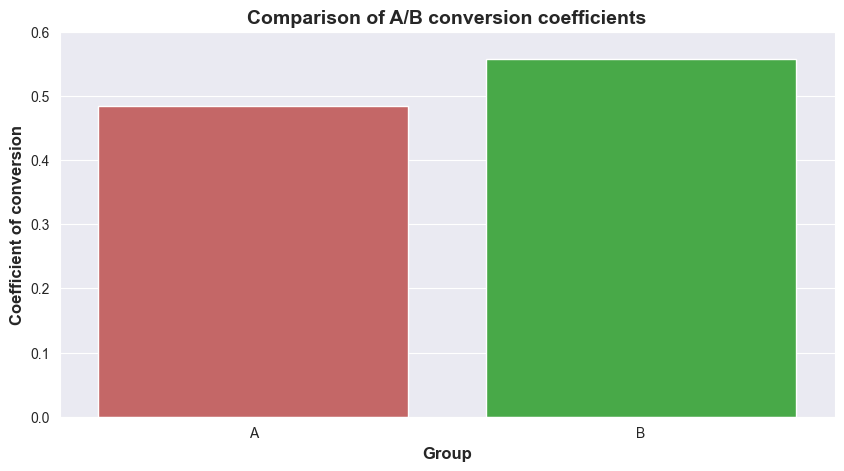

In [201]:
f, ax = plt.subplots(figsize = (10,5))
sns.set_style('darkgrid')

# Столбчатая диаграмма
conv_ratio = ab_groups.groupby(by = 'group')['conversion'].mean()
sns.barplot(x = conv_ratio.index, y = conv_ratio.values, palette = ['#D45757', '#38B938'])
plt.title('Comparison of A/B conversion coefficients', fontsize = 14, fontweight = 'bold')
plt.xlabel('Group', fontsize = 12, fontweight = 'bold')
plt.ylabel('Coefficient of conversion', fontsize = 12, fontweight = 'bold')
plt.ylim(0, 0.6)


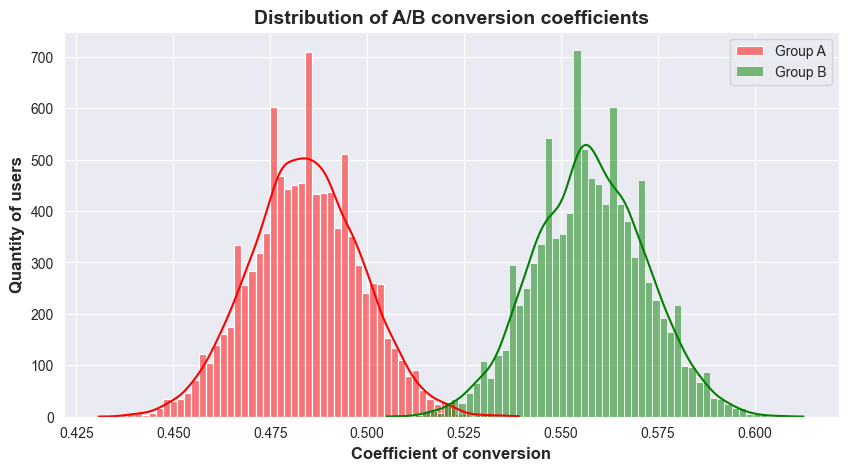

In [202]:
f, ax = plt.subplots(figsize = (10,5))

# Гистограмма распределения
sns.histplot(bootmeans_A, color = 'r', kde = True, label = 'Group A')
sns.histplot(bootmeans_B, color = 'g', kde = True, label = 'Group B')
plt.title('Distribution of A/B conversion coefficients', fontsize = 14, fontweight = 'bold')
plt.xlabel('Coefficient of conversion', fontsize = 12, fontweight = 'bold')
plt.ylabel('Quantity of users', fontsize = 12, fontweight = 'bold')
plt.legend()

Text(0, 0.5, 'Conversion coefficient')

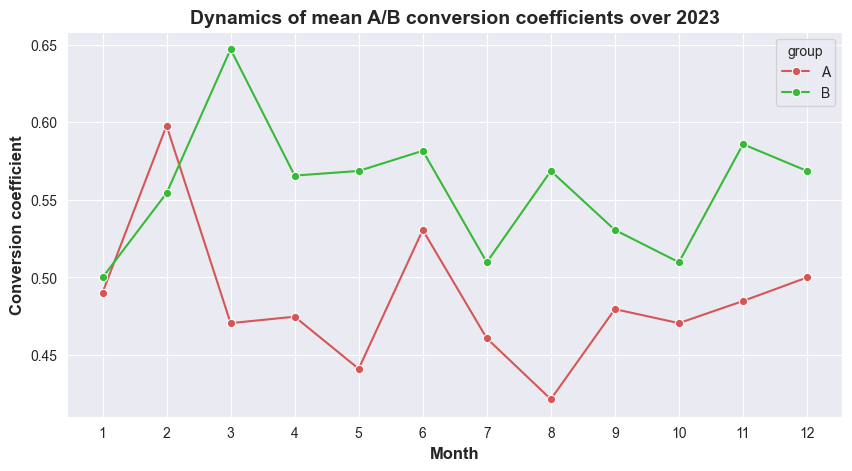

In [203]:
f, ax = plt.subplots(figsize = (10,5))

# Динамика по месяцам для 2023 года
sns.lineplot(data = monthly_meanconv, markers = ['o', 'o'], palette = ['#D45757', '#38B938'], dashes = False)
plt.xticks(range(1, 13, 1))
plt.title('Dynamics of mean A/B conversion coefficients over 2023', fontsize = 14, fontweight = 'bold')
plt.xlabel('Month', fontsize = 12, fontweight = 'bold')
plt.ylabel('Conversion coefficient', fontsize = 12, fontweight = 'bold')

**`Выше`** были представлены графики, учитывающие взаимодействие пользователей с сайтом **`в течение одного года`**. **Теперь** **`смоделируем`** данные для **`6 лет`** и построим для них графики

In [204]:
group_a['timestamps'] = pd.date_range(start = '1/1/2023', end = '31/12/2028 23:59:59', periods = len(group_a)) # - метки времени для взаимодействия пользователей с приложением в 2023-2028 годах
group_b['timestamps'] = pd.date_range(start = '1/1/2023', end = '31/12/2028 23:59:59', periods = len(group_b))
ab_groups = pd.concat([group_a, group_b], ignore_index = True)
ab_groups['month'] = ab_groups['timestamps'].dt.month # - метка времени для месяца
ab_groups['year'] = ab_groups['timestamps'].dt.year # - метка времени для года

# Средний коэффициент конверсии по месяцам и годам с 2023 по 2028 включительно
monthly_meanconv = ab_groups.groupby(by = ['month', 'group'])['conversion'].mean().unstack()
annual_meanconv = ab_groups.groupby(by = ['year', 'group'])['conversion'].mean().unstack()

ab_groups

,group,user_id,conversion,timestamps,month,year
0,A,0,1,2023-01-01 00:00:00.000000000,1,2023
1,A,1,1,2023-01-02 19:52:35.628857381,1,2023
2,A,2,1,2023-01-04 15:45:11.257714762,1,2023
3,A,3,1,2023-01-06 11:37:46.886572143,1,2023
4,A,4,0,2023-01-08 07:30:22.515429524,1,2023
...,...,...,...,...,...,...
2395,B,2395,1,2028-12-24 16:29:36.484570496,12,2028
2396,B,2396,0,2028-12-26 12:22:12.113427872,12,2028
2397,B,2397,0,2028-12-28 08:14:47.742285248,12,2028
2398,B,2398,1,2028-12-30 04:07:23.371142624,12,2028


Text(0, 0.5, 'Conversion coefficient')

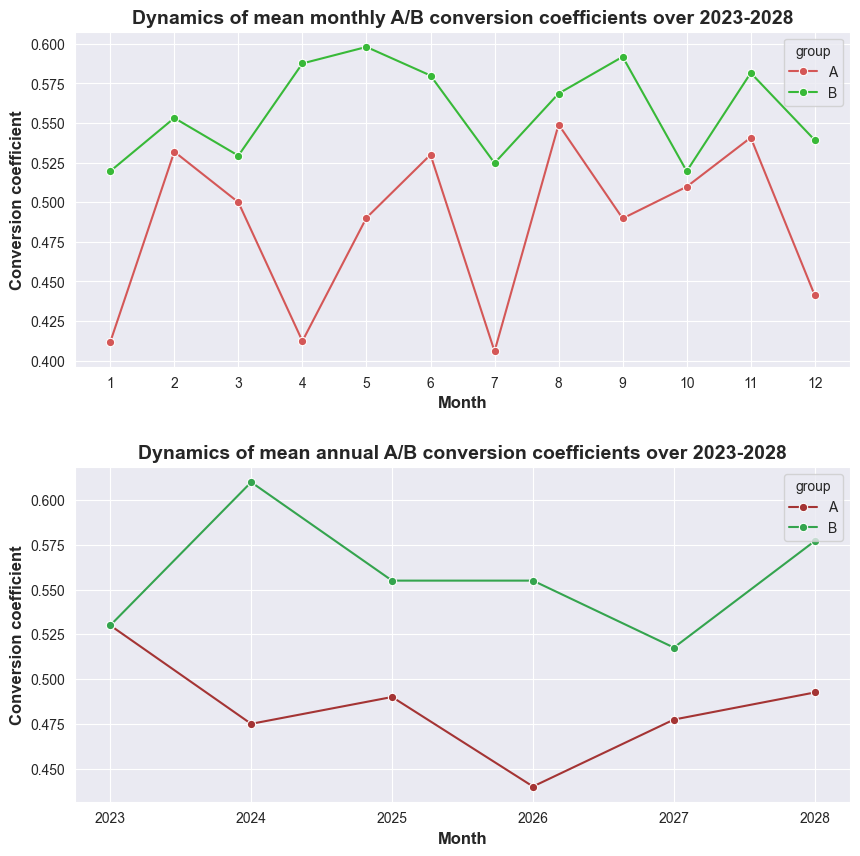

In [205]:
f, ax = plt.subplots(2,1, figsize = (10,10))
sns.set_style('darkgrid')
plt.subplots_adjust(hspace = 0.3)

# Динамика по месяцам для 2023 - 2028 годов
sns.lineplot(data = monthly_meanconv, ax = ax[0], markers = ['o', 'o'], palette = ['#D45757', '#38B938'], dashes = False)
ax[0].set_xticks(range(1, 13, 1))
ax[0].set_title('Dynamics of mean monthly A/B conversion coefficients over 2023-2028', fontsize = 14, fontweight = 'bold')
ax[0].set_xlabel('Month', fontsize = 12, fontweight = 'bold')
ax[0].set_ylabel('Conversion coefficient', fontsize = 12, fontweight = 'bold')

# Динамика по годам для 2023 - 2028 годов
sns.lineplot(data = annual_meanconv, ax = ax[1], markers = ['o', 'o'], palette = ['#A43434', '#34A44E'], dashes = False)
ax[1].set_title('Dynamics of mean annual A/B conversion coefficients over 2023-2028', fontsize = 14, fontweight = 'bold')
ax[1].set_xlabel('Month', fontsize = 12, fontweight = 'bold')
ax[1].set_ylabel('Conversion coefficient', fontsize = 12, fontweight = 'bold')

### **`6)`** Общий вывод по результатам эксперимента

**`Изменение дизайна`** на сайте повлекло за собой **`увеличение конверсии`** **в среднем на** **`7%`**. Сравнивая **графики динамики** конверсии за **несколько лет**, можно увидеть, что средняя конверсия в тестовой **`группе В`** **всегда превышала** среднюю конверсию в контрольной **`группе А`**, как разрезе по годам, так и по месяцам. **Если** учитывать, что **наблюдения** проводились **в рамках одного года**, график динамики средней конверсии по месяцам в **`2023`** году также свидетельствует о **более высоких** показателях конверсии в **`группе В`**. **Также**, был проведен тест **`ХИ-2`**, который **`подтвердил`** **значимость** разделения пользователей на группы. **Таким образом**, **`изменение дизайна`** является **хорошим ходом**, который **`повысил привлекаемость`** сайта и обеспечил **`увеличение`** **количества покупок**.